# Dataset Analysis with Configurable Train / Val / Test Split

In [60]:
# ------------------------------------------------------------
# CONFIG – edit only the variables below
# ------------------------------------------------------------
TRAIN_DATASETS      = ['camcan', 'dallas_lifespan', 'npc', 'nimh_rv', 'oasis3', 'pangen', 'sald', 'corr', 'narratives', 'aomic_id1000']  # example
TEST_DATASETS       = ['ixi']  # IXI as the sole test-set

VAL_FRACTION        = 0.20   # 0.10 → 10 % of TRAIN becomes VAL
RANDOM_STATE        = 42     # reproducible shuffles
DROP_OTHER_DATASETS = True   # ignore rows from datasets not listed

# --- global analysis parameters -------------------------------------------
AGE_MIN, AGE_MAX = 20, 80
MODALITIES       = ['t1', 't2', 'flair']

In [61]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import itertools, warnings, uuid, sys, fnmatch, os
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook')

LABEL_DIR = Path('..') / 'labels'
LABEL_DIR.mkdir(parents=True, exist_ok=True)

In [62]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def clean_df(raw: pd.DataFrame) -> pd.DataFrame:
    """Standardise column names & values, drop unusable rows, and create 5-year age bins."""
    df = raw.copy()
    df.columns = df.columns.str.strip().str.lower()

    # --- age ---------------------------------------------------------------
    df['age'] = pd.to_numeric(df['age'], errors='coerce').round(0)
    df = df.dropna(subset=['age'])
    df['age'] = df['age'].astype('Int64')

    # --- sex ---------------------------------------------------------------
    df['sex'] = (df['sex'].astype(str).str.lower().str.strip()
                   .map({'m':'male','male':'male','1':'male',
                         'f':'female','female':'female','2':'female'}))
    # --- modality ----------------------------------------------------------
    df['modality'] = (df['modality'].astype(str).str.lower()
                        .str.extract('(t1|t2|flair)', expand=False))

    # --- drops & filters ---------------------------------------------------
    df = df.dropna(subset=['sex', 'modality'])
    df = df.query('@AGE_MIN <= age <= @AGE_MAX')

    # --- 5-year age bins ---------------------------------------------------
    bins   = range(AGE_MIN, AGE_MAX + 5, 5)
    labels = [f"{i}-{i+4}" for i in range(AGE_MIN, AGE_MAX, 5)]
    df['5_year_age_bin'] = pd.cut(df['age'], bins=bins, right=False, labels=labels)

    return df

def quick_plots(df: pd.DataFrame, title: str = ''):
    """Quick glance at age + sex distributions."""
    print(f'\n### {title} – shape: {df.shape}\n')
    display(df.head())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.countplot(x='sex', data=df, ax=axes[0]); axes[0].set_title('Sex')
    sns.histplot(df['age'], bins=20, kde=True, ax=axes[1]); axes[1].set_title('Age')
    plt.suptitle(title); plt.tight_layout(); plt.show()

def plot_age_sex_heatmap(df: pd.DataFrame,
                         title: str = '',
                         *,
                         group_by: int = 1,        # age bin width (years)
                         cmap: str   = 'YlGnBu',
                         log_scale: bool = False,
                         save_as: str | None = None):
    """Heat-map of sample counts by AGE×SEX."""
    sexes = ['male', 'female']
    ages  = list(range(AGE_MIN, AGE_MAX + 1, group_by))
    mat   = np.zeros((len(sexes), len(ages)), dtype=int)

    df2 = df.copy()
    df2['age_bin'] = (df2['age'] // group_by) * group_by

    for r, sex in enumerate(sexes):
        sub = df2[df2['sex'] == sex]
        counts = sub.groupby('age_bin').size()
        for c, age in enumerate(ages):
            mat[r, c] = counts.get(age, 0)

    plot_mat = np.log1p(mat) if log_scale else mat
    cbar_lbl = 'logₑ(1 + count)' if log_scale else 'count'

    plt.figure(figsize=(18, 3))
    sns.heatmap(plot_mat,
                cmap=cmap,
                annot=True,
                fmt='.0f',
                linewidths=.5,
                cbar_kws={'label': cbar_lbl},
                xticklabels=ages,
                yticklabels=[s.capitalize() for s in sexes])
    plt.title(title)
    plt.xlabel('Age')
    plt.ylabel('Sex')
    plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150)
    plt.show()

In [63]:
# ------------------------------------------------------------
# Load Excel and concatenate all sheets
# ------------------------------------------------------------
EXCEL_FILE = 'all_datasets_segmented_npy.xlsx'  # change path if needed

sheets = pd.read_excel(EXCEL_FILE, sheet_name=None)
df_list = []
for name, sheet in sheets.items():
    if 'dataset' not in sheet.columns or sheet['dataset'].isna().all():
        sheet['dataset'] = name
    df_list.append(sheet)

df_all = pd.concat(df_list, ignore_index=True)
df_all = clean_df(df_all)
print('Loaded & cleaned data →', df_all.shape)
df_all.to_csv('age_binned_data.csv', index=False)
print(df_all['dataset'].unique())

Loaded & cleaned data → (9089, 7)
['ixi' 'boldvar' 'narratives' 'camcan' 'dallas_lifespan' 'nimh_rv'
 'aomic_id1000' 'npc' 'oasis3' 'corr' 'sald' 'pangen']


In [64]:
nimhrv_filenames = [r"*HighResHippo*"]  # substring patterns

oasis_filenames = [
    r"*sub-OAS31103_ses-d0170_run-01_T1w*",
    r"*sub-OAS30516_ses-d0225_run-01_T1w*",
    r"*sub-OAS30062_ses-d0087_run-01_T1w*",
    r"*sub-OAS30558_ses-d0061_run-01_T1w*",
    r"*sub-OAS30472_ses-d0058_run-01_T1w*",
    r"*sub-OAS30106_ses-d2982_run-01_T1w*",
    r"*sub-OAS30803_ses-d0086_run-01_T1w*",
    r"*sub-OAS30367_ses-d0055_run-01_T1w*",
    r"*sub-OAS30660_ses-d0087_run-01_T1w*",
    r"*sub-OAS30032_ses-d0262_run-01_T1w*",
    r"*sub-OAS30444_ses-d0001_run-04_T1w*",
    r"*sub-OAS30059_ses-d0230_run-01_T1w*",
    r"*sub-OAS30455_ses-d0171_run-01_T1w*",
    r"*sub-OAS30969_ses-d3306_run-01_T1w*",
    r"*sub-OAS30103_ses-d3306_run-01_T1w*",
    r"*sub-OAS31072_ses-d0833_run-01_T1w*",
    r"*sub-OAS30059_ses-d0230_run-04_T1w*",
    r"*sub-OAS30444_ses-d0001_run-01_T1w*",
    r"*sub-OAS30297_ses-d0105_run-01_T1w*",
    r"*sub-OAS30689_ses-d0282_run-01_T1w*",
    r"*sub-OAS30181_ses-d0129_run-01_T1w*",
    r"*sub-OAS30785_ses-d0768_run-01_T1w*",
    r"*sub-OAS30365_ses-d5600_run-01_T1w*",
    r"*sub-OAS30558_ses-d0155_run-01_T1w*",
    r"*sub-OAS30059_ses-d0230_run-01_T1w*",
    r"*sub-OAS30459_ses-d0078_run-01_T1w*"
]

REMOVE_PATTERNS = oasis_filenames + nimhrv_filenames

In [65]:
# ------------------------------------------------------------
# Remove images with certain filename patterns
# ------------------------------------------------------------
col = 'image_path'
print("DataFrame shape before removal:", df_all.shape)

mask = df_all[col].astype(str).apply(lambda x: any(fnmatch.fnmatch(x, p) for p in REMOVE_PATTERNS))
if mask.any():
    print(f"Removing {mask.sum()} rows matching patterns")
    df_all = df_all.loc[~mask].copy()
else:
    print('No rows removed')

DataFrame shape before removal: (9089, 7)
Removing 21 rows matching patterns


### Train / Val / Test Split Summary

In [66]:
# ------------------------------------------------------------
# Explicit TRAIN / VAL / TEST partitions
# ------------------------------------------------------------
train_lower = [d.lower() for d in TRAIN_DATASETS]
test_lower  = [d.lower() for d in TEST_DATASETS]
if set(train_lower) & set(test_lower):
    raise ValueError('A dataset appears in both TRAIN_DATASETS and TEST_DATASETS')

is_train = df_all['dataset'].str.lower().isin(train_lower)
is_test  = df_all['dataset'].str.lower().isin(test_lower)

if DROP_OTHER_DATASETS:
    df_all = df_all[is_train | is_test].copy()

df_train_full = df_all[is_train].copy()
df_test       = df_all[is_test ].copy()

def stratified_train_val_split(df: pd.DataFrame, stratify_cols: list, val_fraction: float, random_state: int):
    group_counts = df.groupby(stratify_cols).size()
    valid_groups = group_counts[group_counts >= 2].index
    mask_valid   = df.set_index(stratify_cols).index.isin(valid_groups)
    df_valid     = df[mask_valid]
    df_rare      = df[~mask_valid]

    train, val = train_test_split(
        df_valid,
        test_size=val_fraction,
        random_state=random_state,
        stratify=df_valid[stratify_cols]
    )
    train = pd.concat([train, df_rare], ignore_index=True)
    return train.reset_index(drop=True), val.reset_index(drop=True)

# Define datasets to exclude from validation set
VAL_EXCLUDE_DATASETS = ['sald', 'pangen', 'corr', 'aomic_id1000']  

if VAL_FRACTION > 0 and not df_train_full.empty:
    # Filter out datasets that should be excluded from validation
    val_exclude_lower = [d.lower() for d in VAL_EXCLUDE_DATASETS]
    is_val_excluded = df_train_full['dataset'].str.lower().isin(val_exclude_lower)
    
    # Split only the data that can go into validation
    df_train_eligible = df_train_full[~is_val_excluded].copy()
    df_train_excluded = df_train_full[is_val_excluded].copy()
    
    if not df_train_eligible.empty:
        df_train_split, df_val = stratified_train_val_split(
            df_train_eligible,
            stratify_cols=['modality', 'sex', '5_year_age_bin'],
            val_fraction=VAL_FRACTION,
            random_state=RANDOM_STATE
        )
        # Combine training split with excluded datasets (they all go to training)
        df_train = pd.concat([df_train_split, df_train_excluded], ignore_index=True)
    else:
        # If all datasets are excluded from validation, everything goes to training
        df_train = df_train_full.copy()
        df_val = pd.DataFrame(columns=df_all.columns)
else:
    df_train = df_train_full.copy()
    df_val   = pd.DataFrame(columns=df_all.columns)

print(f"Rows used  : {len(df_all):,}")
print(f"  TRAIN : {len(df_train):,}")
print(f"  VAL   : {len(df_val):,}")
print(f"  TEST  : {len(df_test):,}")

Rows used  : 8,766
  TRAIN : 6,669
  VAL   : 940
  TEST  : 1,157


In [67]:
# ------------------------------------------------------------
# Build BALANCED TEST set (≤4 samples per (age, sex, modality))
# ------------------------------------------------------------
def balance_test_set(df: pd.DataFrame, max_per_combo: int = 4) -> pd.DataFrame:
    grouped = df.groupby(['age', 'sex', 'modality'], group_keys=False)
    return grouped.apply(lambda g: g.sample(n=min(max_per_combo, len(g)), random_state=RANDOM_STATE))\
                 .reset_index(drop=True)

df_test_balanced = balance_test_set(df_test)
print(f'Original TEST size : {len(df_test):,}')
print(f'Balanced TEST size : {len(df_test_balanced):,}')

Original TEST size : 1,157
Balanced TEST size : 808


In [68]:
# ------------------------------------------------------------
# Compute sample weights – AGE only
# ------------------------------------------------------------
def add_sample_weights_by_age(df: pd.DataFrame) -> pd.DataFrame:
    """Add inverse-frequency sample weights based solely on integer AGE."""
    df = df.copy()
    df['age_int'] = df['age'].astype(int)
    freq = df.groupby('age_int').size().rename('freq')
    df = df.join(freq, on='age_int')
    df['sample_weight'] = 1.0 / df['freq']
    df['sample_weight'] /= df['sample_weight'].sum()
    return df.drop(columns=['age_int', 'freq'])

df_train = add_sample_weights_by_age(df_train)
df_val   = add_sample_weights_by_age(df_val)   if not df_val.empty else df_val
df_test  = add_sample_weights_by_age(df_test)
df_test_balanced = add_sample_weights_by_age(df_test_balanced)

### Age & Sex Statistics + Heat-maps


=== TRAIN STATISTICS ===

         count  mean   std   min   25%   50%   75%   max
sex                                                     
female  3735.0  43.0  19.2  20.0  24.0  38.0  61.0  80.0
male    2934.0  42.6  19.9  20.0  24.0  36.0  63.0  80.0

Count by sex:
 female    3735
male      2934
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    6669.0
mean       42.9
std        19.5
min        20.0
25%        24.0
50%        37.0
75%        62.0
max        80.0
Name: age, dtype: Float64


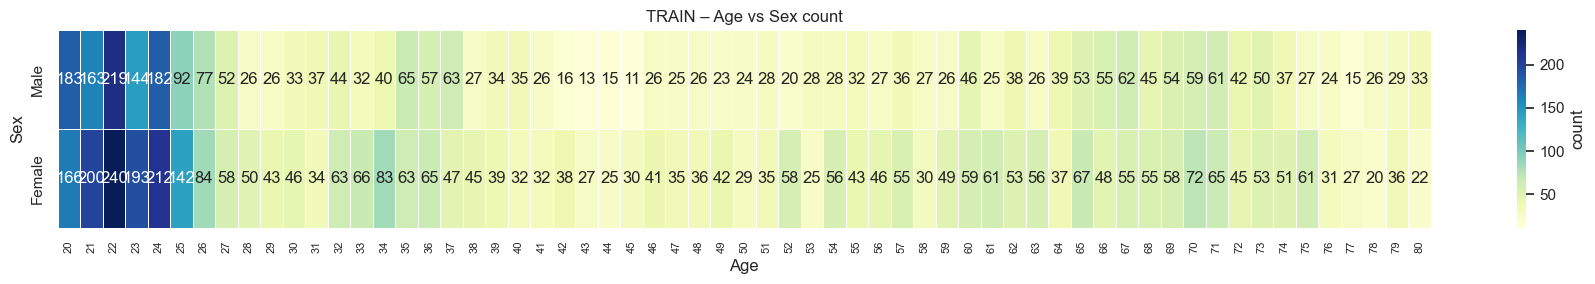


=== VAL STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  545.0  50.5  18.4  20.0  33.0  54.0  67.0  79.0
male    395.0  51.6  18.2  20.0  35.0  55.0  68.0  79.0

Count by sex:
 female    545
male      395
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    940.0
mean      51.0
std       18.3
min       20.0
25%       33.0
50%       54.0
75%       68.0
max       79.0
Name: age, dtype: Float64


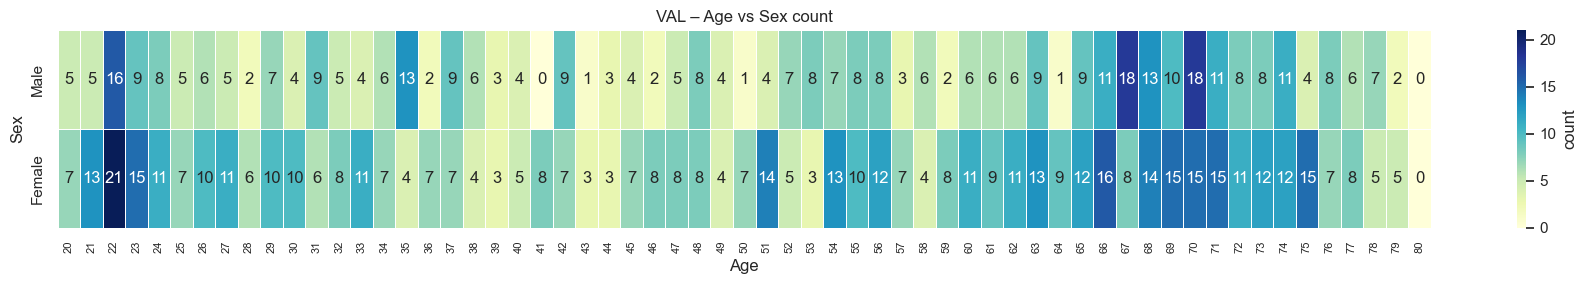


=== TEST_BALANCED STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  424.0  49.8  17.0  20.0  35.0  50.0  64.2  80.0
male    384.0  48.0  16.2  20.0  34.0  48.0  62.0  79.0

Count by sex:
 female    424
male      384
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    808.0
mean      49.0
std       16.6
min       20.0
25%       34.0
50%       49.0
75%       63.0
max       80.0
Name: age, dtype: Float64


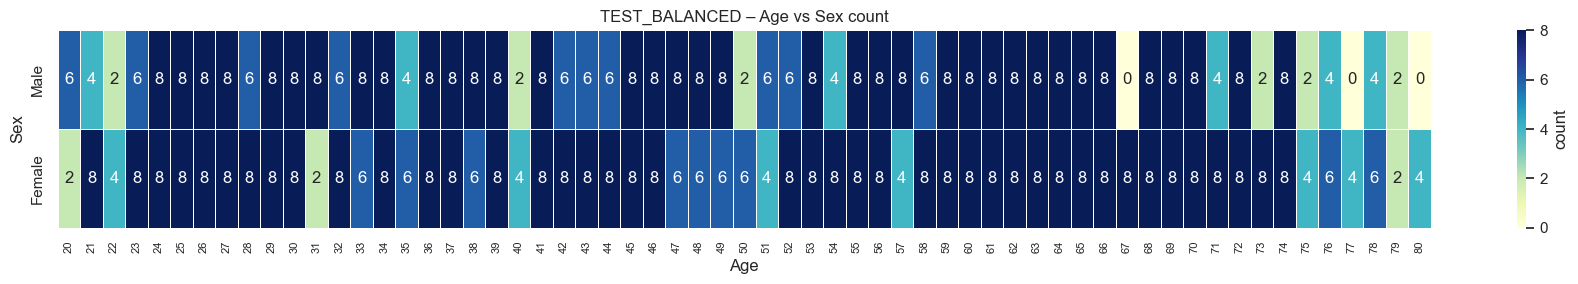


=== FULL STATISTICS ===

         count  mean   std   min   25%   50%   75%   max
sex                                                     
female  4932.0  44.9  19.1  20.0  25.0  43.0  62.0  80.0
male    3834.0  44.1  19.5  20.0  24.0  39.0  64.0  80.0

Count by sex:
 female    4932
male      3834
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    8766.0
mean       44.5
std        19.2
min        20.0
25%        25.0
50%        41.0
75%        63.0
max        80.0
Name: age, dtype: Float64


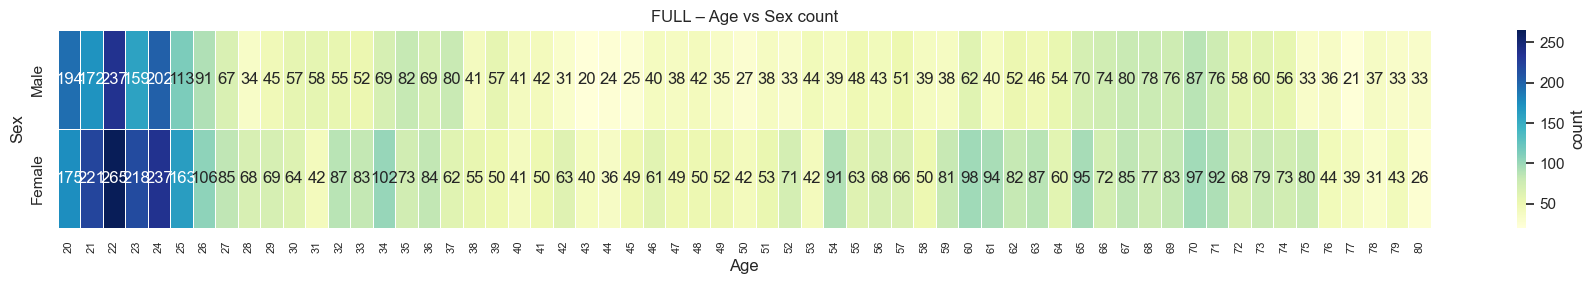


=== DATASET AOMIC_ID1000 STATISTICS ===

        count  mean  std   min   25%   50%   75%   max
sex                                                   
female  483.0  22.8  1.8  20.0  22.0  23.0  24.0  26.0
male    444.0  22.9  1.8  20.0  21.0  23.0  24.0  26.0

Count by sex:
 female    483
male      444
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    927.0
mean      22.8
std        1.8
min       20.0
25%       21.0
50%       23.0
75%       24.0
max       26.0
Name: age, dtype: Float64


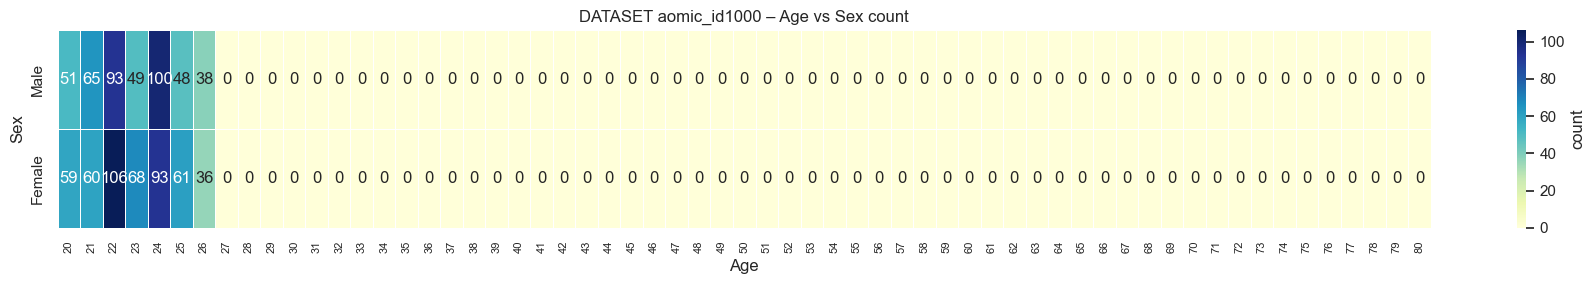


=== DATASET CAMCAN STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  608.0  52.1  17.2  20.0  37.0  51.0  67.0  80.0
male    590.0  53.2  16.8  20.0  38.0  54.0  68.0  80.0

Count by sex:
 female    608
male      590
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    1198.0
mean       52.7
std        17.0
min        20.0
25%        38.0
50%        52.0
75%        68.0
max        80.0
Name: age, dtype: Float64


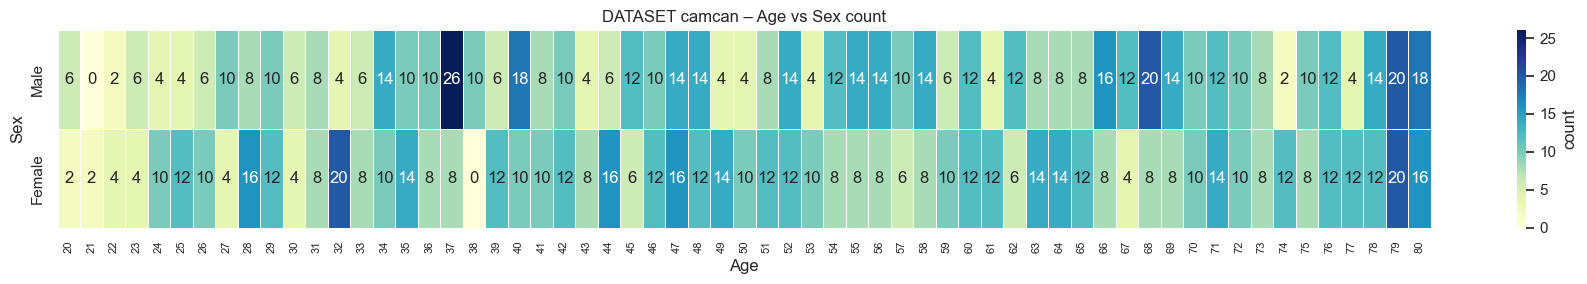


=== DATASET CORR STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  513.0  30.2  14.5  20.0  21.0  24.0  32.0  79.0
male    534.0  31.3  16.3  20.0  21.0  23.0  31.0  79.0

Count by sex:
 male      534
female    513
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    1047.0
mean       30.7
std        15.5
min        20.0
25%        21.0
50%        23.0
75%        31.5
max        79.0
Name: age, dtype: Float64


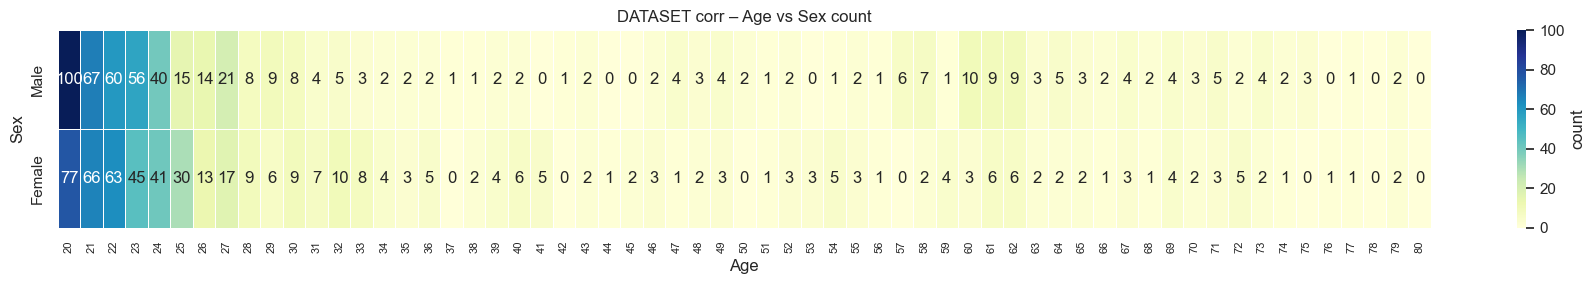


=== DATASET DALLAS_LIFESPAN STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  516.0  55.0  16.4  21.0  43.0  58.0  69.0  80.0
male    310.0  55.1  16.8  21.0  43.2  59.0  69.0  80.0

Count by sex:
 female    516
male      310
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    826.0
mean      55.1
std       16.5
min       21.0
25%       43.0
50%       58.0
75%       69.0
max       80.0
Name: age, dtype: Float64


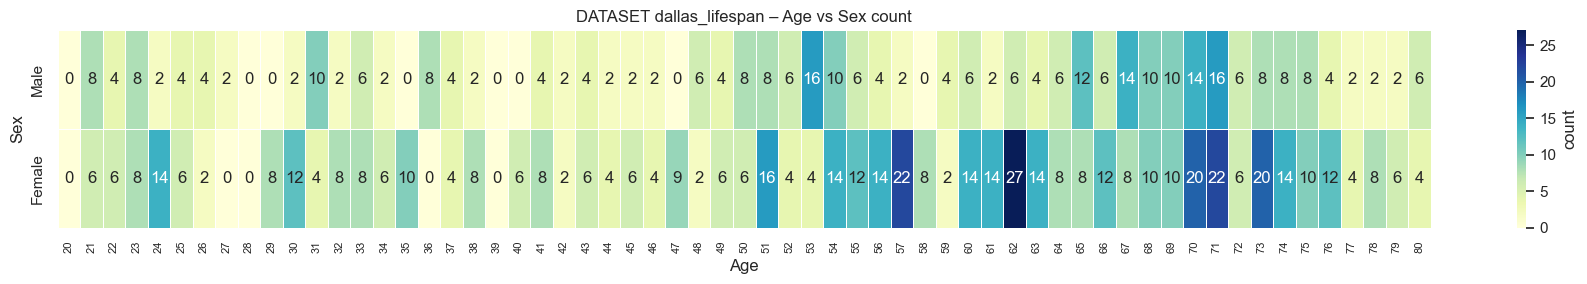


=== DATASET IXI STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  652.0  50.6  16.3  20.0  36.0  54.0  63.0  80.0
male    505.0  46.8  16.1  20.0  33.0  45.0  61.0  79.0

Count by sex:
 female    652
male      505
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    1157.0
mean       49.0
std        16.3
min        20.0
25%        34.0
50%        50.0
75%        63.0
max        80.0
Name: age, dtype: Float64


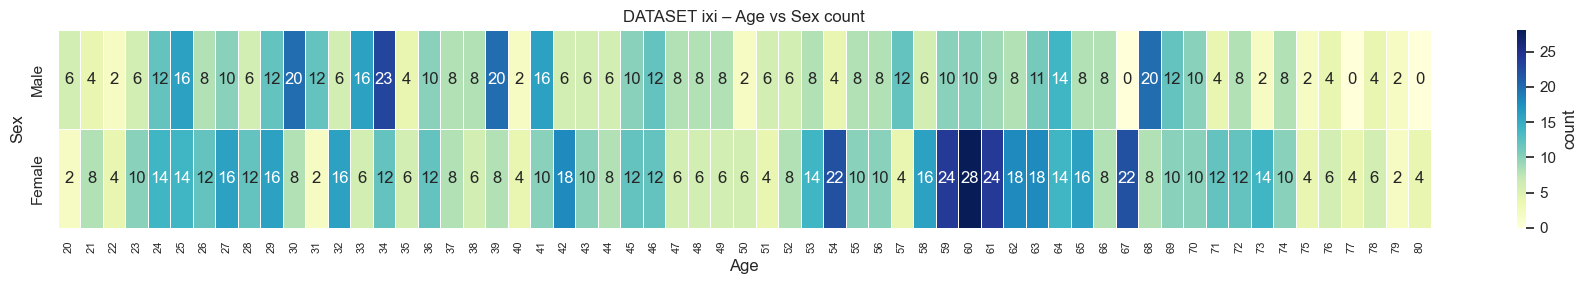


=== DATASET NARRATIVES STATISTICS ===

        count  mean  std   min   25%   50%   75%   max
sex                                                   
female  137.0  22.9  3.4  20.0  21.0  21.0  24.0  38.0
male     95.0  24.3  6.5  20.0  21.0  22.0  25.0  53.0

Count by sex:
 female    137
male       95
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    232.0
mean      23.4
std        4.9
min       20.0
25%       21.0
50%       22.0
75%       25.0
max       53.0
Name: age, dtype: Float64


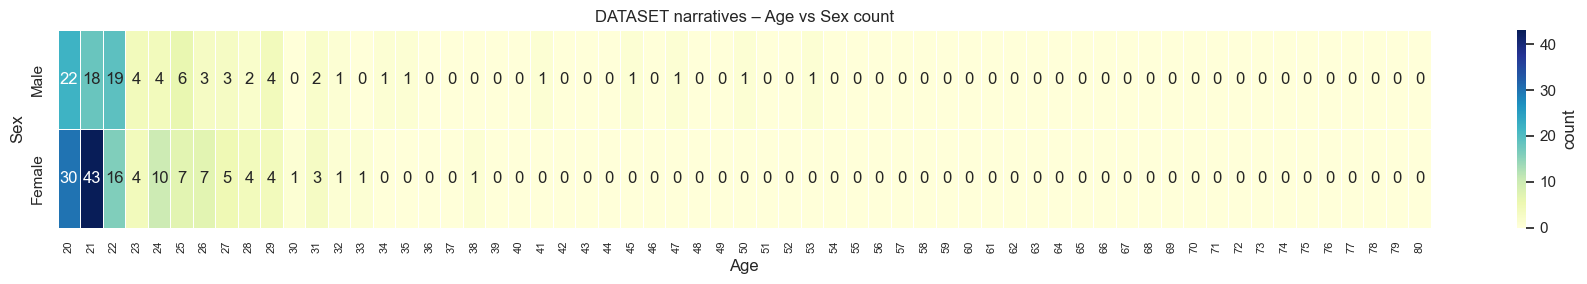


=== DATASET NIMH_RV STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  574.0  34.5  11.2  21.0  25.0  32.0  42.0  65.0
male    348.0  34.2  11.4  20.0  25.0  32.0  39.0  72.0

Count by sex:
 female    574
male      348
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    922.0
mean      34.4
std       11.3
min       20.0
25%       25.0
50%       32.0
75%       41.0
max       72.0
Name: age, dtype: Float64


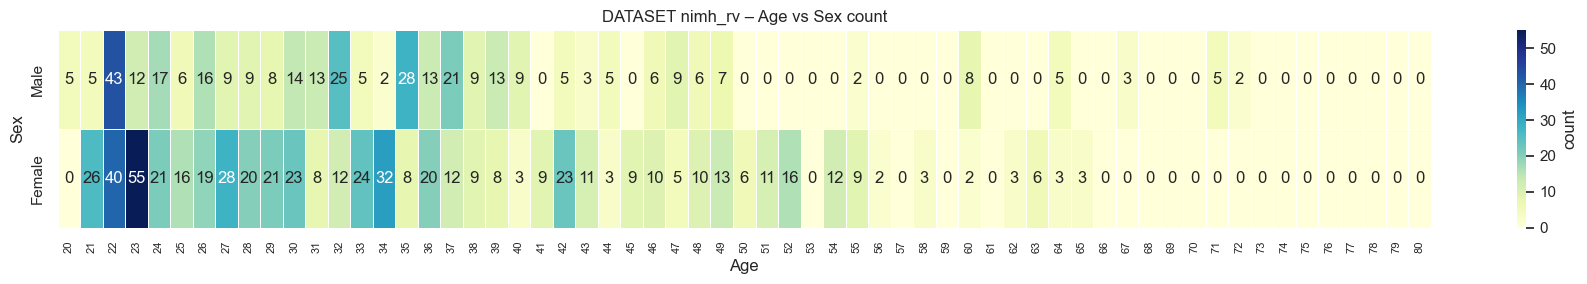


=== DATASET NPC STATISTICS ===

        count  mean  std   min   25%   50%   75%   max
sex                                                   
female   72.0  26.4  4.0  21.0  23.5  25.0  29.2  34.0
male     60.0  26.9  4.6  20.0  23.0  25.0  31.0  35.0

Count by sex:
 female    72
male      60
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    132.0
mean      26.6
std        4.3
min       20.0
25%       23.0
50%       25.0
75%       30.0
max       35.0
Name: age, dtype: Float64


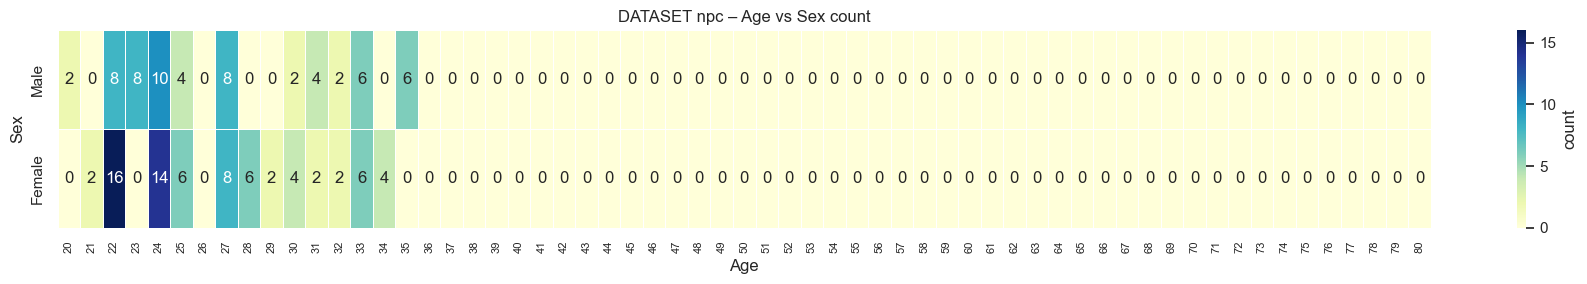


=== DATASET OASIS3 STATISTICS ===

        count  mean  std   min   25%   50%   75%   max
sex                                                   
female  843.0  65.1  8.1  43.0  60.0  67.0  71.0  80.0
male    600.0  66.5  7.8  42.0  63.0  68.0  72.0  80.0

Count by sex:
 female    843
male      600
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    1443.0
mean       65.7
std         8.0
min        42.0
25%        61.0
50%        67.0
75%        71.0
max        80.0
Name: age, dtype: Float64


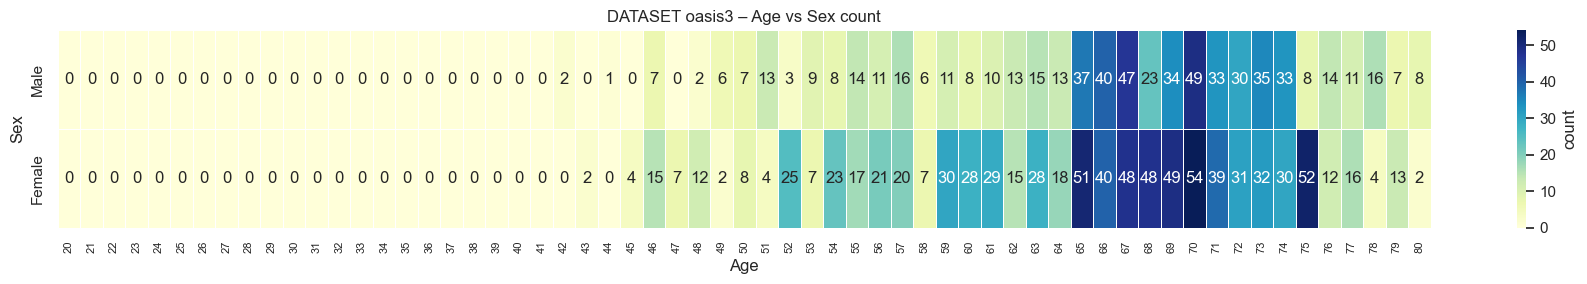


=== DATASET PANGEN STATISTICS ===

        count  mean  std   min   25%   50%   75%   max
sex                                                   
female  231.0  35.8  2.6  27.0  34.0  36.0  38.0  42.0
male    161.0  36.5  4.3  31.0  34.0  36.0  38.0  77.0

Count by sex:
 female    231
male      161
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    392.0
mean      36.1
std        3.4
min       27.0
25%       34.0
50%       36.0
75%       38.0
max       77.0
Name: age, dtype: Float64


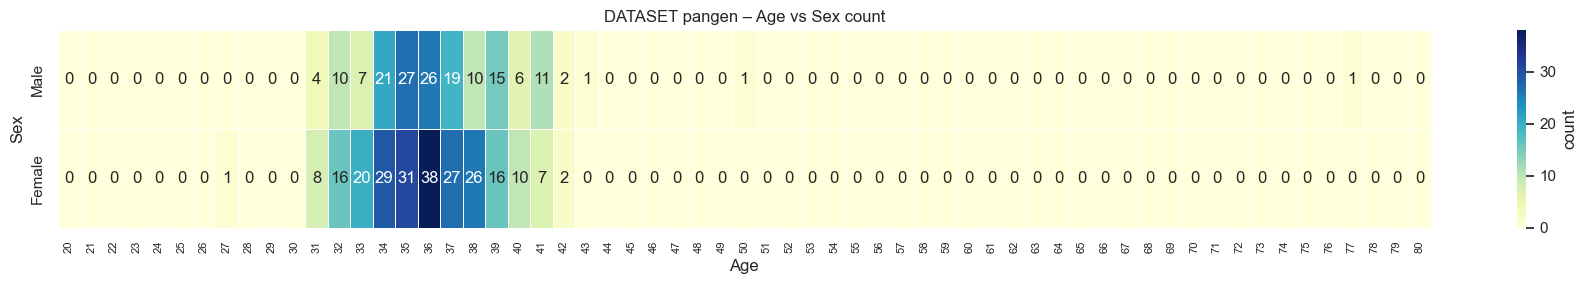


=== DATASET SALD STATISTICS ===

        count  mean   std   min   25%   50%   75%   max
sex                                                    
female  303.0  45.3  17.2  20.0  25.0  48.0  59.0  78.0
male    187.0  45.6  17.7  20.0  26.0  48.0  60.0  80.0

Count by sex:
 female    303
male      187
Name: sex, dtype: int64

Overall age descriptive statistics:
 count    490.0
mean      45.4
std       17.4
min       20.0
25%       25.0
50%       48.0
75%       59.0
max       80.0
Name: age, dtype: Float64


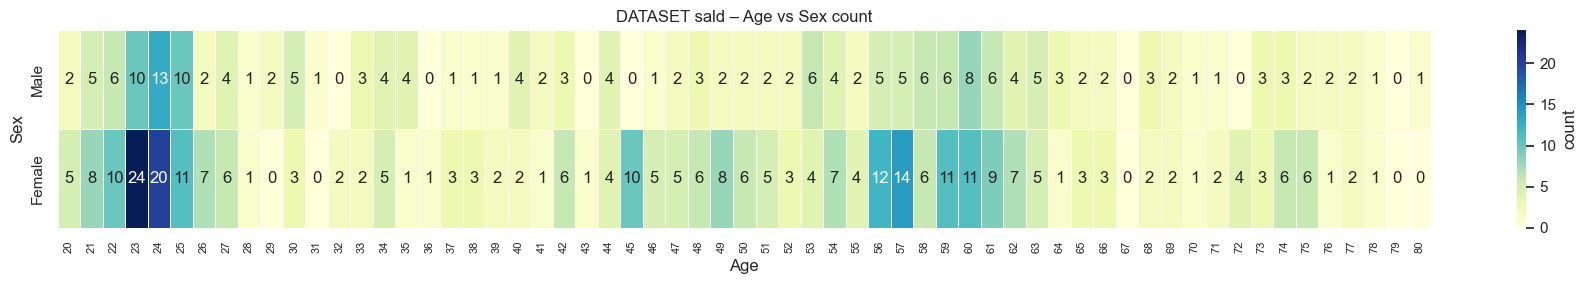

In [69]:
# ------------------------------------------------------------
# Statistical analysis on AGE & SEX + heat-maps
# ------------------------------------------------------------
def age_sex_summary(df: pd.DataFrame, name: str):
    """Print descriptive AGE × SEX statistics and show a heat-map."""
    print(f"\n=== {name.upper()} STATISTICS ===\n")
    if df.empty:
        print('Empty dataframe – skipping.')
        return
    print(df.groupby('sex')['age'].describe().round(1))
    print("\nCount by sex:\n", df['sex'].value_counts())
    print("\nOverall age descriptive statistics:\n", df['age'].describe().round(1))
    plot_age_sex_heatmap(df, title=f'{name} – Age vs Sex count')

# --- partition-level summaries -------------------------------------------
age_sex_summary(df_train, 'TRAIN')
if not df_val.empty:
    age_sex_summary(df_val, 'VAL')
age_sex_summary(df_test_balanced, 'TEST_BALANCED')
age_sex_summary(df_all, 'FULL')

# --- per-dataset summaries ------------------------------------------------
for ds_name, df_ds in df_all.groupby('dataset'):
    age_sex_summary(df_ds, f'DATASET {ds_name}')

In [70]:
# ------------------------------------------------------------
# Save split CSV files
# ------------------------------------------------------------
df_train.to_csv(LABEL_DIR / 'train.csv', index=False)
df_val.to_csv(LABEL_DIR / 'val.csv',   index=False)
df_test.to_csv(LABEL_DIR / 'test.csv', index=False)
df_test_balanced.to_csv(LABEL_DIR / 'test_balanced.csv', index=False)

print(f'Saved CSVs to {LABEL_DIR.resolve()}')

Saved CSVs to /Users/andrasjoos/Documents/AI_masters/Thesis/thesis_project/brain_age_pred/data/labels


### Train Set Analysis


### TRAIN set – shape: (6669, 8)



,subject_id,image_path,sex,age,modality,dataset,5_year_age_bin,sample_weight
0,sub-CC510568,CamCAN/sub-CC510568_T1w.nii.npy,male,60,t1,camcan,60-64,0.000156
1,sub-ON83320,NIMH_RV/sub-ON83320_ses-01_acq-3dCUBE_rec-SCIC...,female,51,flair,nimh_rv,50-54,0.000260
2,sub-ON04111,NIMH_RV/sub-ON04111_ses-01_acq-CUBE_rec-SCIC_r...,female,39,t2,nimh_rv,35-39,0.000225
3,sub-CC510161,CamCAN/sub-CC510161_T2w.nii.npy,male,58,t2,camcan,55-59,0.000288
4,sub-CC121158,CamCAN/sub-CC121158_T2w.nii.npy,female,28,t2,camcan,25-29,0.000216


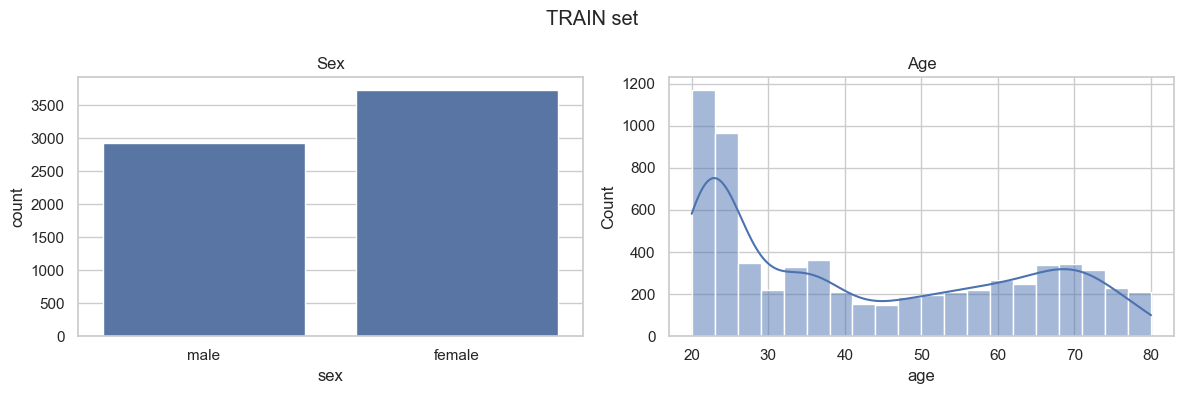

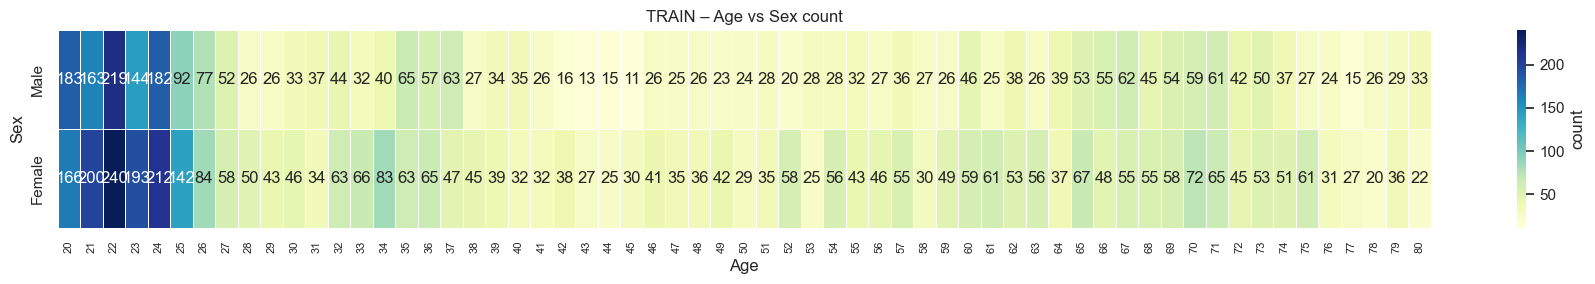

In [71]:
quick_plots(df_train, 'TRAIN set')
plot_age_sex_heatmap(df_train, 'TRAIN – Age vs Sex count')

### Validation Set Analysis


### VAL set – shape: (940, 8)



,subject_id,image_path,sex,age,modality,dataset,5_year_age_bin,sample_weight
0,sub-ON97515,NIMH_RV/sub-ON97515_ses-01_acq-CUBE_T2w.nii.npy,female,42,t2,nimh_rv,40-44,0.001042
1,sub-OAS30427,OASIS/OASIS3/sub-OAS30427_ses-d4348_T1w.nii.npy,female,54,t1,oasis3,50-54,0.000833
2,sub-335,OpenNeuro/DallasLifeSpan/sub-335_ses-wave1_acq...,female,62,t2,dallas_lifespan,60-64,0.000980
3,sub-OAS31136,OASIS/OASIS3/sub-OAS31136_ses-d0156_T1w.nii.npy,male,67,t1,oasis3,65-69,0.000641
4,sub-OAS30264,OASIS/OASIS3/sub-OAS30264_ses-d0466_T1w.nii.npy,female,66,t1,oasis3,65-69,0.000617


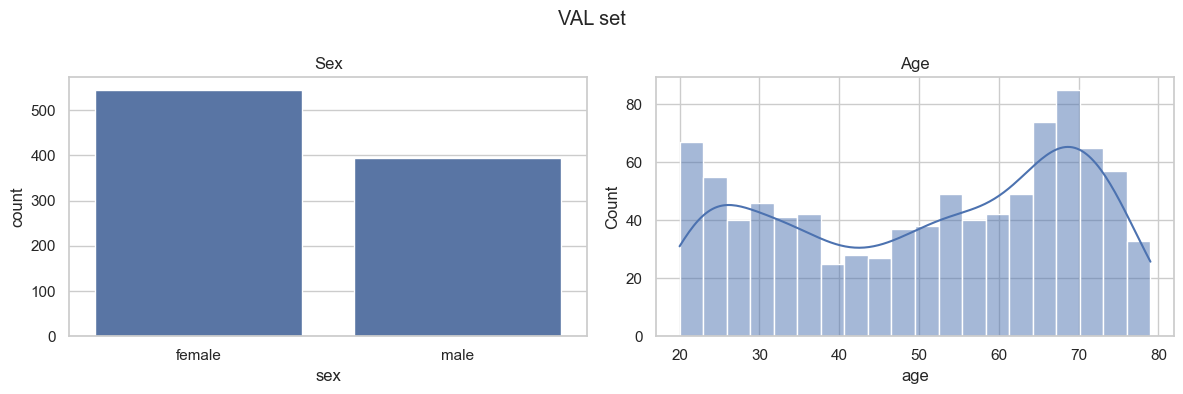

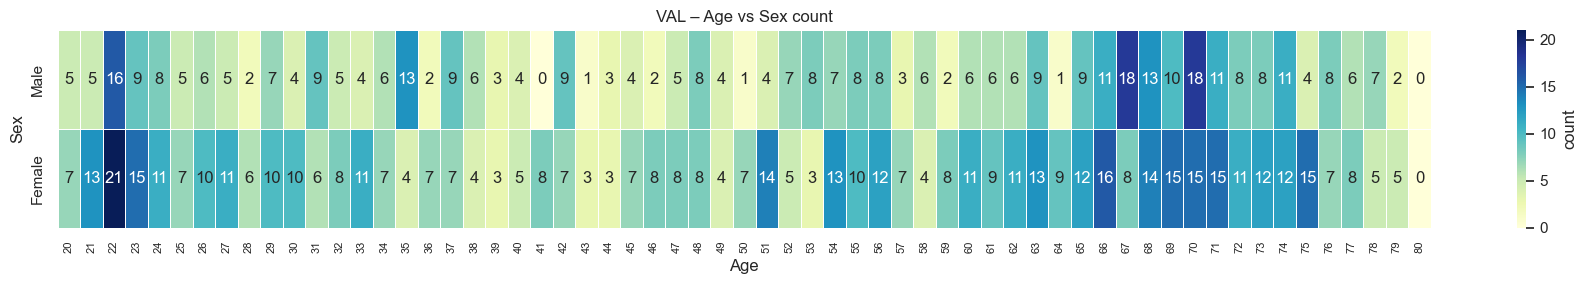

In [72]:
if not df_val.empty:
    quick_plots(df_val, 'VAL set')
    plot_age_sex_heatmap(df_val, 'VAL – Age vs Sex count')
else:
    print('VAL set is empty – no analysis performed.')

### Test Set Analysis (Balanced)


### TEST_BALANCED set – shape: (808, 8)



,subject_id,image_path,sex,age,modality,dataset,5_year_age_bin,sample_weight
0,IXI425-IOP-0988,IXI/IXI425-IOP-0988-T1.nii.npy,female,20,t1,ixi,20-24,0.002049
1,IXI425-IOP-0988,IXI/IXI425-IOP-0988-T2.nii.npy,female,20,t2,ixi,20-24,0.002049
2,IXI064-Guys-0743,IXI/IXI064-Guys-0743-T1.nii.npy,male,20,t1,ixi,20-24,0.002049
3,IXI202-HH-1526,IXI/IXI202-HH-1526-T1.nii.npy,male,20,t1,ixi,20-24,0.002049
4,IXI278-HH-1771,IXI/IXI278-HH-1771-T1.nii.npy,male,20,t1,ixi,20-24,0.002049


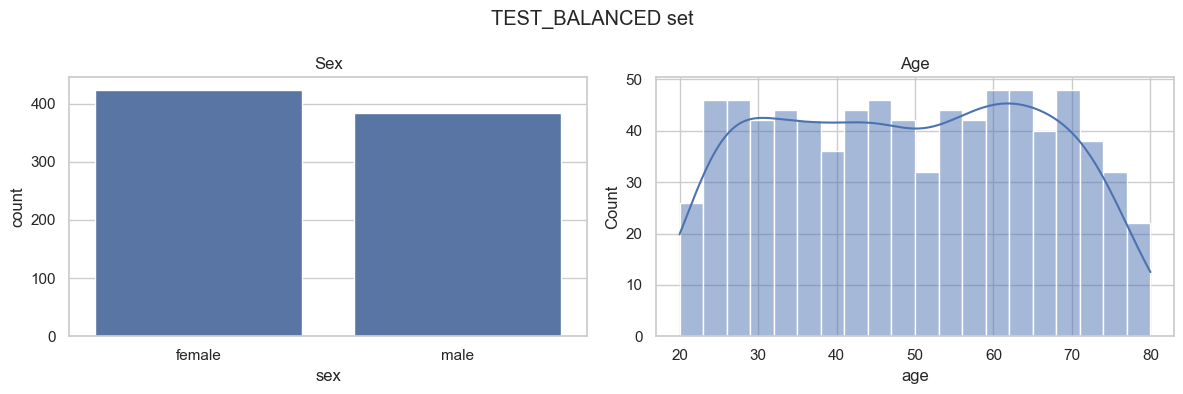

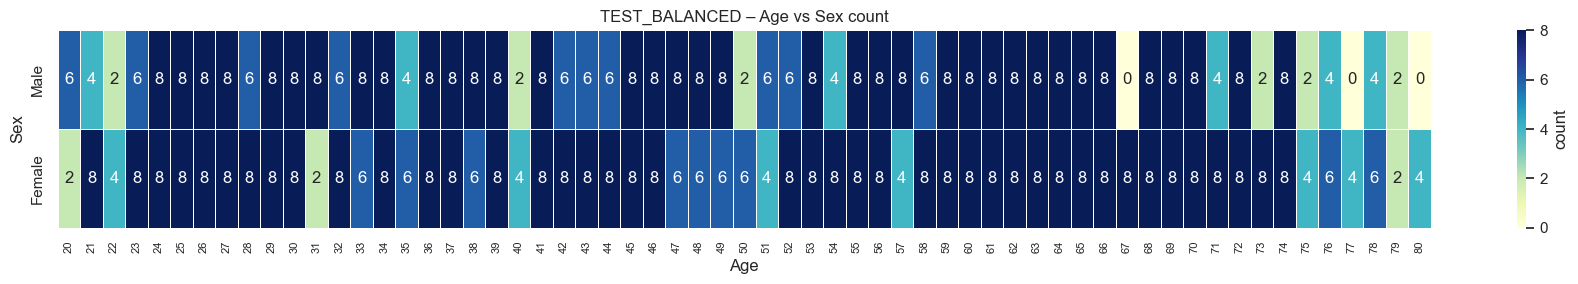

In [73]:
quick_plots(df_test_balanced, 'TEST_BALANCED set')
plot_age_sex_heatmap(df_test_balanced, 'TEST_BALANCED – Age vs Sex count')

### Full Dataset Analysis


### FULL dataset (used rows only) – shape: (8766, 7)



,subject_id,image_path,sex,age,modality,dataset,5_year_age_bin
0,IXI002-Guys-0828,IXI/IXI002-Guys-0828-T1.nii.npy,female,36,t1,ixi,35-39
1,IXI002-Guys-0828,IXI/IXI002-Guys-0828-T2.nii.npy,female,36,t2,ixi,35-39
2,IXI012-HH-1211,IXI/IXI012-HH-1211-T1.nii.npy,male,39,t1,ixi,35-39
3,IXI012-HH-1211,IXI/IXI012-HH-1211-T2.nii.npy,male,39,t2,ixi,35-39
4,IXI013-HH-1212,IXI/IXI013-HH-1212-T1.nii.npy,male,47,t1,ixi,45-49


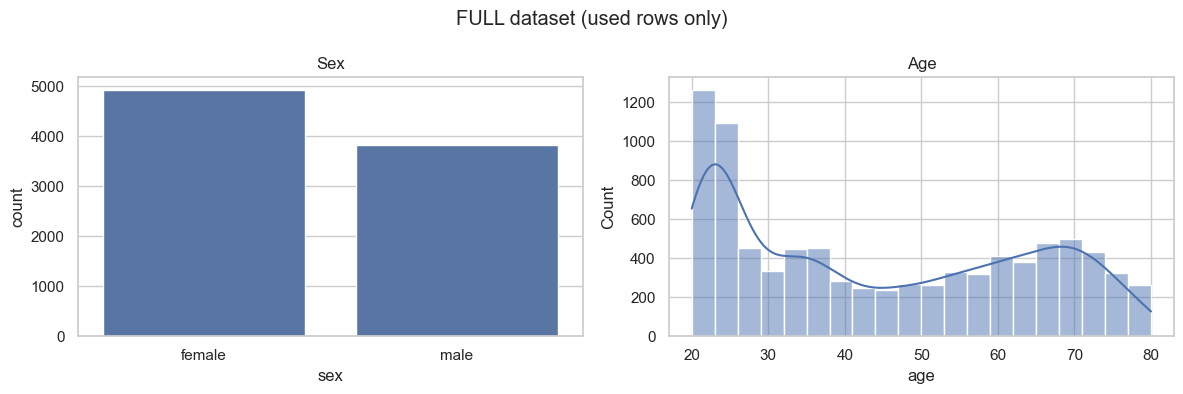

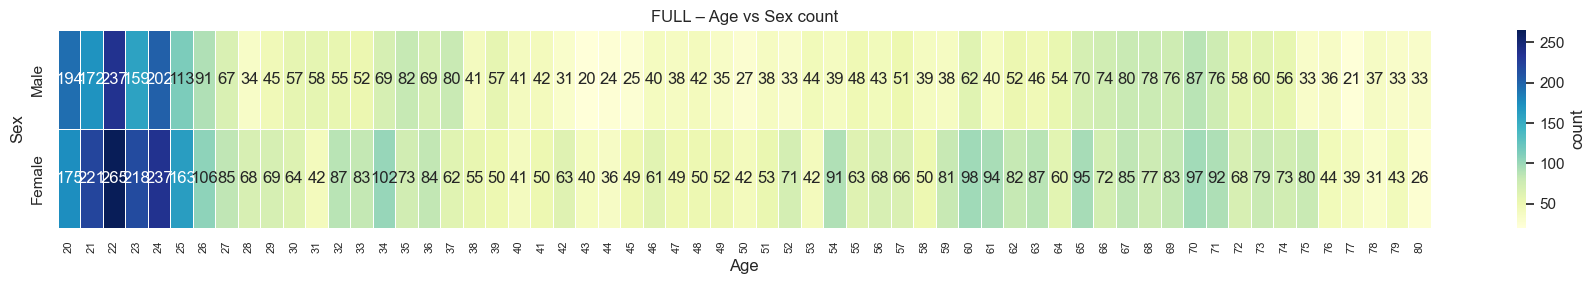

Number of unique subjects: 5613


In [74]:
quick_plots(df_all, 'FULL dataset (used rows only)')
plot_age_sex_heatmap(df_all, 'FULL – Age vs Sex count')
print(f"Number of unique subjects: {df_all['subject_id'].nunique()}")